# BRCA Spatial Transcriptomics — Notebook 4
## Going further: hypothesis-generating analyses

Notebooks 1–3 *described* the tissue. This notebook *asks new questions* of it, using only
the data already in hand:

1. **Marker genes per domain** — define each domain by its top genes (full gene set), not
   just by cell-type proportions.
2. **The tumor invasive interface** — compare tumor spots at the *boundary* with stroma vs
   tumor spots in the *core*. This is where unjamming / partial EMT is expected, so we look
   for EMT and motility genes enriched at the front.
3. **Does morphology predict molecular state?** — train a classifier to predict the domain
   from H&E image features alone, quantifying the structure–state coupling.

> One slide → any finding here is a **hypothesis**, to be validated on a cohort. That framing
> is deliberate, not a hedge.

## 0 · Setup & rebuild a FULL-gene object

Sections 1–2 need *all* genes (the deconvolution object kept only ~1442 shared genes). So we
reload the raw slide (full genes), restrict to the analyzed spots, and attach the labels we
already computed: `domain`, the Cancer-Epithelial proportion (to define tumor spots), and the
H&E `morphology` features (for section 3).

In [2]:
!pip install -q scanpy squidpy scikit-learn

import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd
import scanpy as sc, squidpy as sq
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")
WORKDIR = "/content/drive/MyDrive/brca_spatial"
final = sc.read_h5ad(os.path.join(WORKDIR, "brca_visium_final.h5ad"))
print("final object (deconvolved):", final.shape)

Mounted at /content/drive
final object (deconvolved): (3157, 1442)


In [3]:
# reload full-gene raw slide and align to the analyzed spots
adata = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_1")
adata.var_names_make_unique()
adata = adata[final.obs_names].copy()

# carry over labels from the final object (barcode-aligned)
adata.obs["domain"]            = final.obs.loc[adata.obs_names, "domain"].values
adata.obs["Cancer Epithelial"] = final.obs.loc[adata.obs_names, "Cancer Epithelial"].values
adata.obsm["morphology"]       = final.obsm["morphology"].loc[adata.obs_names]

# normalize for DE (keep raw counts in a layer)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("full-gene object ready:", adata.shape)

  0%|          | 0.00/9.50M [00:00<?, ?B/s]

  0%|          | 0.00/26.9M [00:00<?, ?B/s]

full-gene object ready: (3157, 36601)


## 1 · Marker genes per domain (full gene set)

Realizes the earlier idea of using *all* genes, not the deconvolution intersection. A
Wilcoxon test ranks, for each domain, the genes most specifically up vs all other domains.
This gives each GNN domain a **gene-level identity** that we never imposed from the reference
— so unexpected markers can surface.

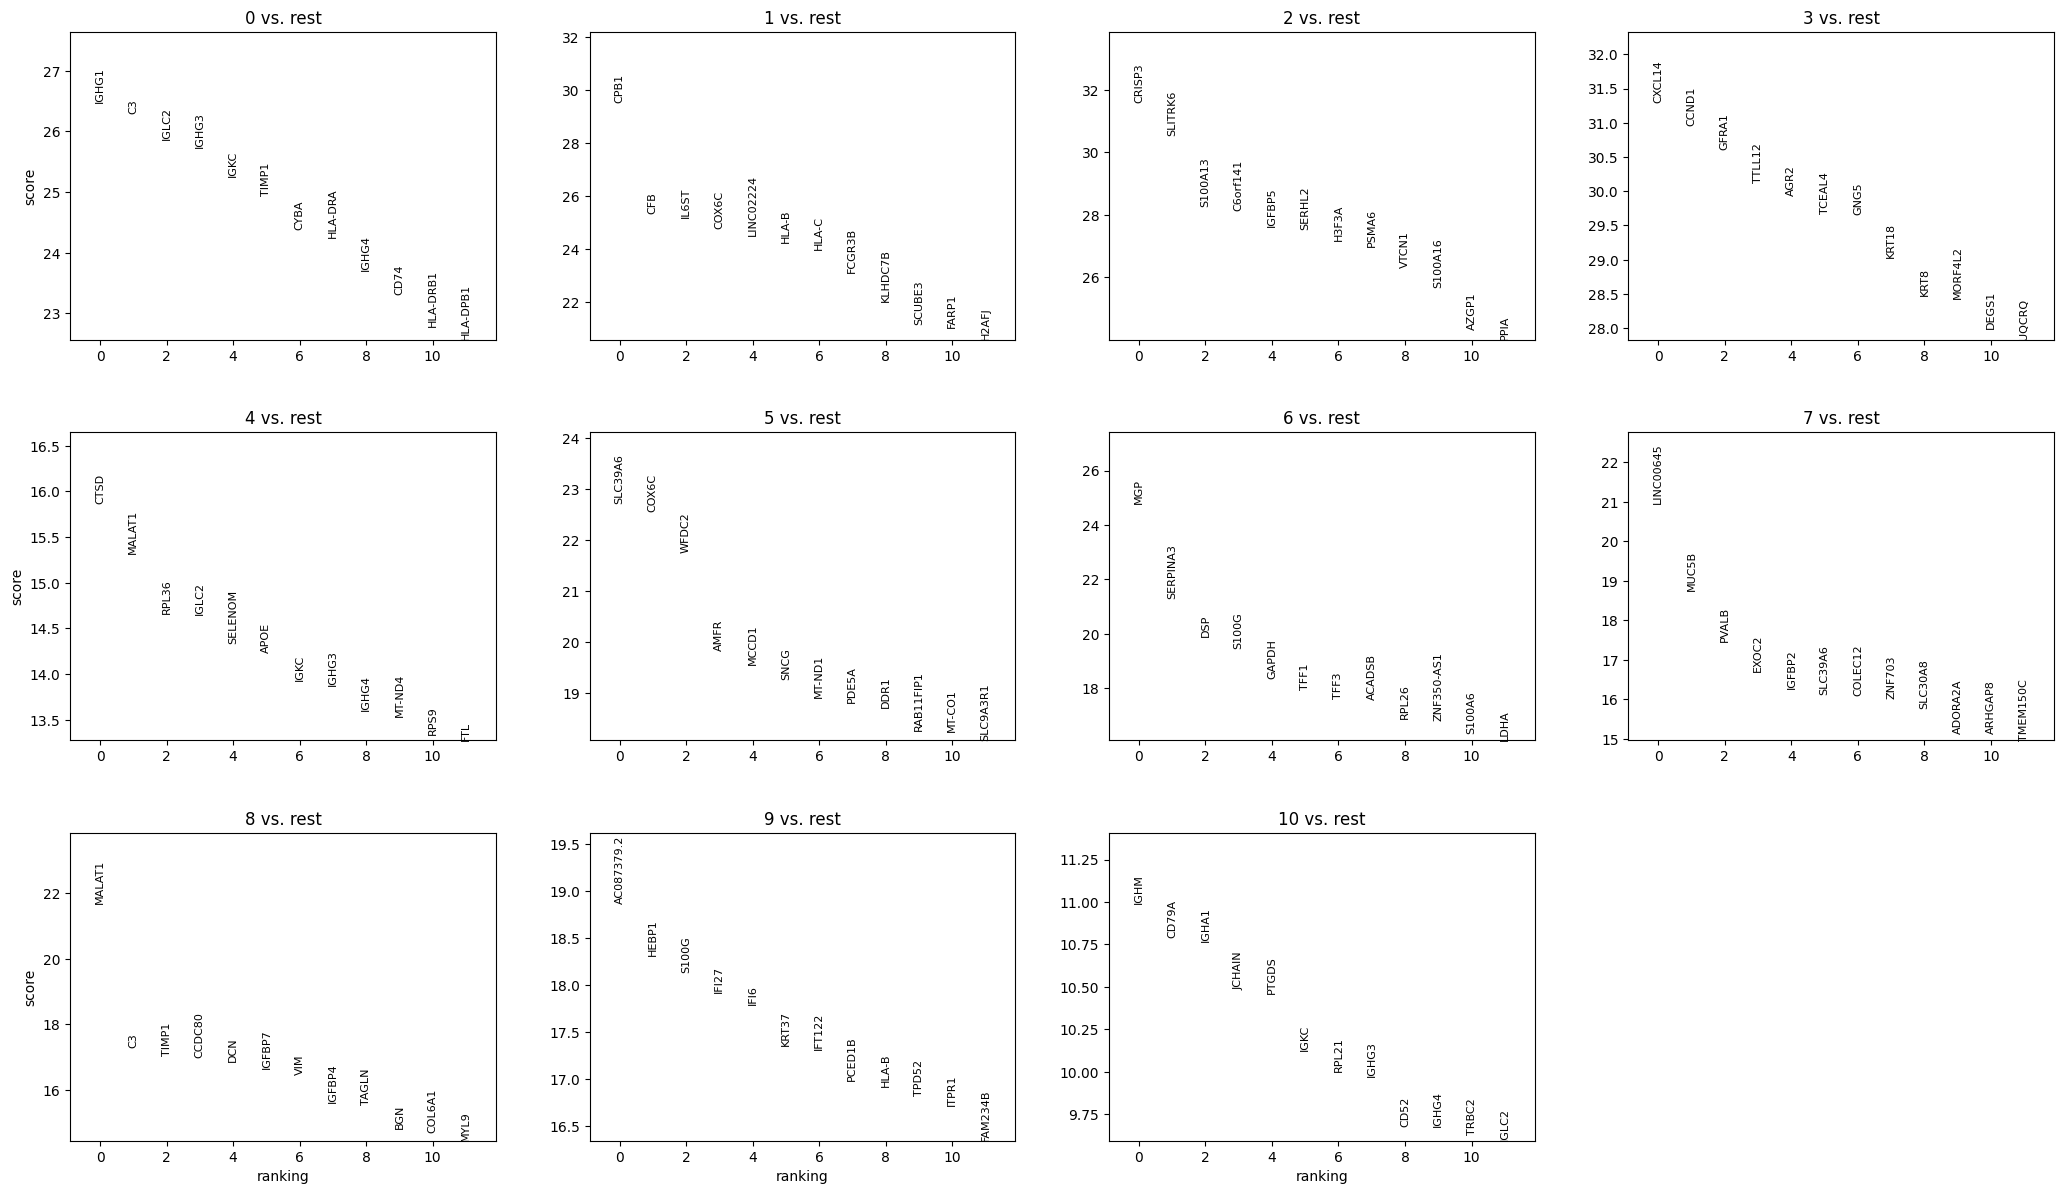

In [6]:
sc.tl.rank_genes_groups(adata, groupby="domain", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=12, sharey=False, fontsize=8)

In [8]:
import pandas as pd, scanpy as sc, numpy as np

# le metriche QC non sono in final.obs (final è stato ricostruito in NB2) -> le calcolo ora
final.var["mt"] = final.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(final, qc_vars=["mt"], percent_top=None,
                           log1p=False, inplace=True)

qc = final.obs.groupby("domain", observed=True)[
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
].mean()
print(qc.round(1))

        total_counts  n_genes_by_counts  pct_counts_mt
domain                                                
0        1083.099976              159.3            0.0
1        1205.800049              196.8            0.0
2        1213.099976              196.5            0.0
3        1406.400024              217.7            0.0
4         739.000000              144.5            0.0
5         818.200012              171.3            0.0
6        1247.500000              192.6            0.0
7         803.099976              162.7            0.0
8         288.500000               99.9            0.0
9        1215.199951              197.6            0.0
10       1223.400024              169.8            0.0


In [10]:
# top 8 markers per domain as a table
top = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(8)
top
##column heads indicate domains

,0,1,2,3,4,5,6,7,8,9,10
0,IGHG1,CPB1,CRISP3,CXCL14,CTSD,SLC39A6,MGP,LINC00645,MALAT1,AC087379.2,IGHM
1,C3,CFB,SLITRK6,CCND1,MALAT1,COX6C,SERPINA3,MUC5B,C3,HEBP1,CD79A
2,IGLC2,IL6ST,S100A13,GFRA1,RPL36,WFDC2,DSP,PVALB,TIMP1,S100G,IGHA1
3,IGHG3,COX6C,C6orf141,TTLL12,IGLC2,AMFR,S100G,EXOC2,CCDC80,IFI27,JCHAIN
4,IGKC,LINC02224,IGFBP5,AGR2,SELENOM,MCCD1,GAPDH,IGFBP2,DCN,IFI6,PTGDS
5,TIMP1,HLA-B,SERHL2,TCEAL4,APOE,SNCG,TFF1,SLC39A6,IGFBP7,KRT37,IGKC
6,CYBA,HLA-C,H3F3A,GNG5,IGKC,MT-ND1,TFF3,COLEC12,VIM,IFT122,RPL21
7,HLA-DRA,FCGR3B,PSMA6,KRT18,IGHG3,PDE5A,ACADSB,ZNF703,IGFBP4,PCED1B,IGHG3


## 2 · The tumor invasive interface — boundary vs core

**The thesis link.** Tumor cells at the *invasive front* (bordering stroma) are where
**unjamming** and **partial EMT** are expected — cells loosen from the jammed epithelial
sheet and become motile. Spatial data lets us isolate those spots and ask what they express
differently from tumor cells buried in the core.

We define tumor spots (high Cancer-Epithelial proportion), then use the spatial graph to
split them: a **boundary** tumor spot has non-tumor neighbors; a **core** tumor spot is
surrounded by tumor. Then we test which genes are up at the boundary.

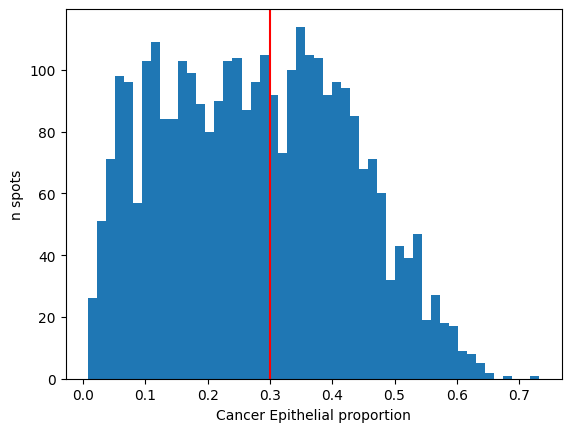

In [11]:
import matplotlib.pyplot as plt
plt.hist(adata.obs["Cancer Epithelial"], bins=50)
plt.xlabel("Cancer Epithelial proportion"); plt.ylabel("n spots")
plt.axvline(0.3, color="red"); plt.show()

In [12]:
# spatial graph + tumor mask
sq.gr.spatial_neighbors(adata, coord_type="grid", n_neighs=6)
A = (adata.obsp["spatial_connectivities"] > 0).astype(int)

tumor = (adata.obs["Cancer Epithelial"].values > 0.25)          # tumor spot definition: 50% or more of the cells in the spot are tumour cells
n_nb       = np.asarray(A.sum(1)).ravel()
n_tumor_nb = np.asarray(A.dot(tumor.astype(int))).ravel()
frac_tumor = np.divide(n_tumor_nb, n_nb, out=np.zeros(adata.n_obs), where=n_nb > 0)

zone = np.array(["non-tumor"] * adata.n_obs, dtype=object)
zone[tumor & (frac_tumor >= 0.8)] = "tumor-core"        # almost all neighbors tumor
zone[tumor & (frac_tumor <  0.8)] = "tumor-boundary"    # touches non-tumor = at the front
adata.obs["tumor_zone"] = pd.Categorical(zone)
print(adata.obs["tumor_zone"].value_counts())

INFO     Creating graph using `None` transform and `1` libraries.                                                  
tumor_zone
non-tumor         1411
tumor-core        1224
tumor-boundary     522
Name: count, dtype: int64


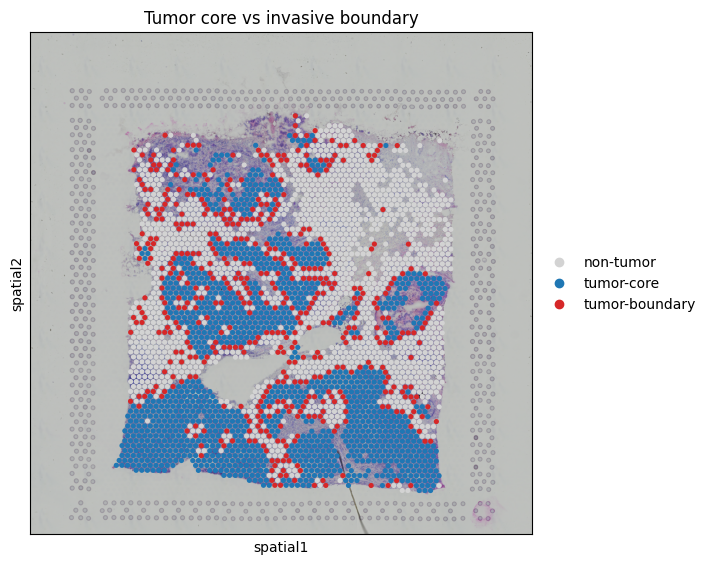

In [13]:
# ordina le categorie e assegna i colori nell'ordine giusto
order = ["non-tumor", "tumor-core", "tumor-boundary"]
adata.obs["tumor_zone"] = adata.obs["tumor_zone"].cat.reorder_categories(order)
adata.uns["tumor_zone_colors"] = ["lightgrey", "#1f77b4", "#d62728"]  # stesso ordine

sq.pl.spatial_scatter(adata, color="tumor_zone", size=1.4, figsize=(7, 7),
                      title="Tumor core vs invasive boundary")

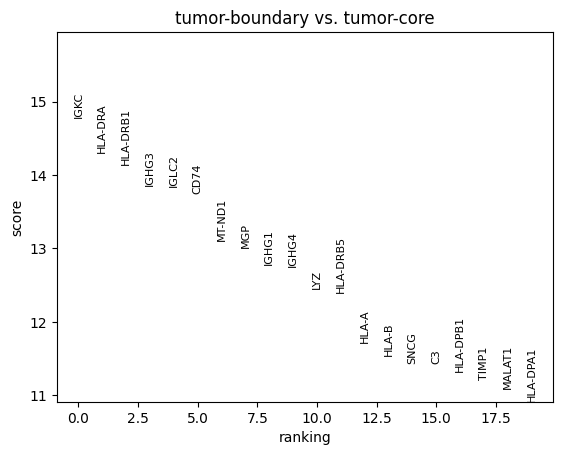

In [14]:
# differential expression: boundary vs core
sub = adata[adata.obs["tumor_zone"].isin(["tumor-core", "tumor-boundary"])].copy()
sc.tl.rank_genes_groups(sub, "tumor_zone", groups=["tumor-boundary"],
                        reference="tumor-core", method="wilcoxon")
sc.pl.rank_genes_groups(sub, n_genes=20, fontsize=8,
                        title="Genes up at the invasive boundary (vs core)")

In [15]:
# targeted look at EMT / unjamming / matrix-remodeling genes
emt = ["VIM","ZEB1","ZEB2","SNAI1","SNAI2","TWIST1","CDH2","CDH1",
       "FN1","MMP2","MMP9","MMP14","SPARC","TGFB1","COL1A1"]
present = [g for g in emt if g in sub.var_names]
res = sc.get.rank_genes_groups_df(sub, group="tumor-boundary")
res = res[res["names"].isin(present)].set_index("names")
print("EMT / motility genes, boundary vs core (logFC>0 = up at front):")
res[["logfoldchanges", "pvals_adj"]].round(3).sort_values("logfoldchanges", ascending=False)

EMT / motility genes, boundary vs core (logFC>0 = up at front):


,logfoldchanges,pvals_adj
names,,
ZEB2,0.484,1.000
ZEB1,0.360,1.000
VIM,0.271,0.000
MMP9,0.211,0.034
MMP2,0.090,0.712
TWIST1,0.075,1.000
SNAI1,0.071,1.000
TGFB1,0.063,1.000
SPARC,0.049,0.881


Genes with **positive logFC** are higher at the invasive boundary. Up-regulation of
mesenchymal/motility markers (VIM, ZEB1/2, SNAI1/2, CDH2, FN1, MMPs) at the front, and/or
loss of E-cadherin (CDH1), would be the transcriptional shadow of unjamming / partial EMT

## 3 · Does H&E morphology predict molecular state?

Notebook 3 showed image texture *differs* across domains. Here we make that quantitative:
train a classifier to predict the **domain** from the **H&E image features alone**. If it
beats chance substantially, tissue *appearance* predicts molecular identity — meaning a cheap
H&E image carries information about (expensive) molecular composition.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

X = adata.obsm["morphology"].values         # H&E features only — no genes
y = adata.obs["domain"].astype(str).values

cv = StratifiedKFold(5, shuffle=True, random_state=0)
clf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
y_pred = cross_val_predict(clf, X, y, cv=cv)

acc   = balanced_accuracy_score(y, y_pred)
chance = 1.0 / len(np.unique(y))
print(f"balanced accuracy from H&E features: {acc:.2f}")
print(f"chance level (random):              {chance:.2f}")
print(f"-> morphology predicts domain {acc/chance:.1f}x better than chance")

balanced accuracy from H&E features: 0.53
chance level (random):              0.09
-> morphology predicts domain 5.8x better than chance


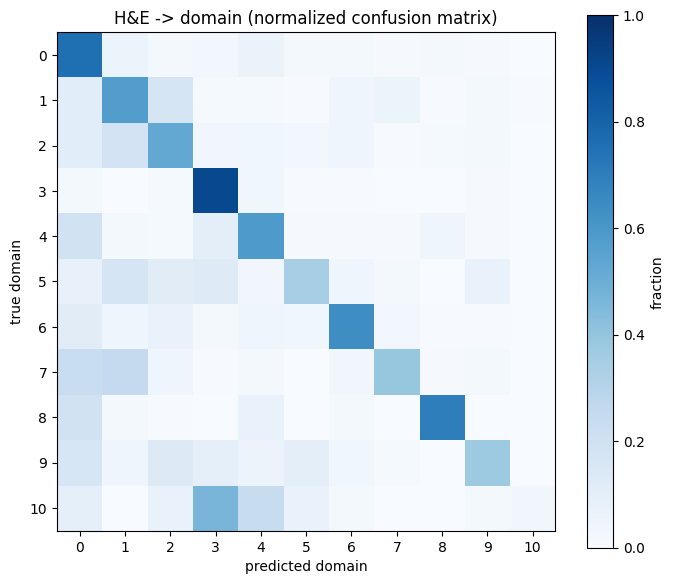

In [17]:
# confusion matrix: which domains are morphologically confusable?
labels = sorted(np.unique(y), key=int)
cm = confusion_matrix(y, y_pred, labels=labels, normalize="true")
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(len(labels)), labels); plt.yticks(range(len(labels)), labels)
plt.xlabel("predicted domain"); plt.ylabel("true domain")
plt.colorbar(label="fraction"); plt.title("H&E -> domain (normalized confusion matrix)")
plt.tight_layout(); plt.show()

A strong diagonal means morphology alone recovers the molecular domains. Off-diagonal
blocks reveal which domains *look alike* under H&E despite differing molecularly — itself
interesting. **Practical implication:** if H&E predicts molecular domains, routine histology
could flag molecularly distinct regions without sequencing — a hypothesis worth testing on a
cohort.

## 4 · Save


In [18]:
adata.write(os.path.join(WORKDIR, "brca_visium_extended.h5ad"))
print("saved extended object with markers, tumor_zone, and morphology")

saved extended object with markers, tumor_zone, and morphology


---
### Summary of new questions asked
- **Domain markers** give each region a gene-level identity (full transcriptome).
- **Invasive-front DE** generates a hypothesis about unjamming/EMT at the tumor boundary —
  the molecular echo of your thesis's mechanics.
- **Morphology classifier** quantifies how strongly tissue appearance predicts molecular
  state. All single-slide → hypotheses for cohort-level validation.